In [1]:
import joblib
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import shap
import numpy as np

In [ ]:

model = joblib.load("..\data\publication_output\dataset\models\gbm_all_patients.joblib")
dataset = pd.read_csv("..\data\publication_output\dataset\survival_feature_matrix.csv", index_col=0)
val_dataset = pd.read_csv("..\data\publication_output\d_mannheim\survival_feature_matrix.csv", index_col=0)

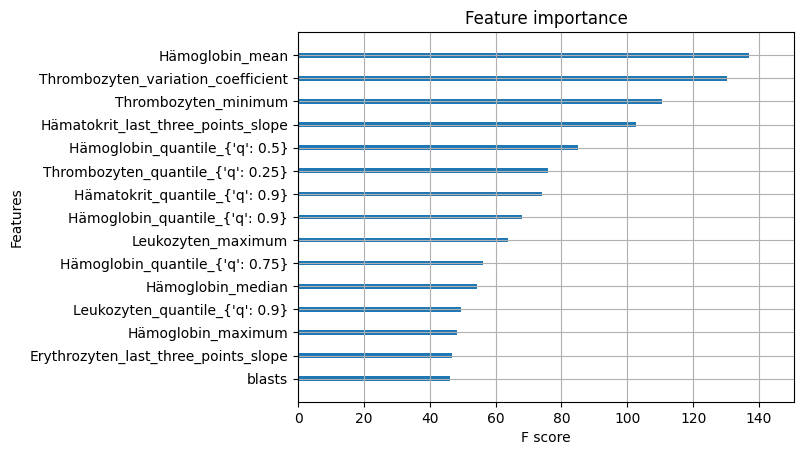

In [3]:
xgb.plot_importance(model, importance_type='gain', max_num_features=15, show_values=False)
#plt.title("Feature importance (Gain)")
plt.savefig("feature_importance.svg")

In [4]:
importance_dict = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'gain': list(importance_dict.values())
})

# Sort by gain descending and get top 20 features
top_features = importance_df.sort_values(by='gain', ascending=False)['feature'].head(20).tolist()
top_features

['Hämoglobin_mean',
 'Thrombozyten_variation_coefficient',
 'Thrombozyten_minimum',
 'Hämatokrit_last_three_points_slope',
 "Hämoglobin_quantile_{'q': 0.5}",
 "Thrombozyten_quantile_{'q': 0.25}",
 "Hämatokrit_quantile_{'q': 0.9}",
 "Hämoglobin_quantile_{'q': 0.9}",
 'Leukozyten_maximum',
 "Hämoglobin_quantile_{'q': 0.75}",
 'Hämoglobin_median',
 "Leukozyten_quantile_{'q': 0.9}",
 'Hämoglobin_maximum',
 'Erythrozyten_last_three_points_slope',
 'blasts',
 "Thrombozyten_quantile_{'q': 0.1}",
 'Hämoglobin_last_three_points_slope',
 'cyto',
 'Hämoglobin_last_location_of_maximum',
 'quarters']

In [5]:
dataset = dataset[model.feature_names_in_]

In [6]:
dataset.shape

(6145, 153)

In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(dataset)

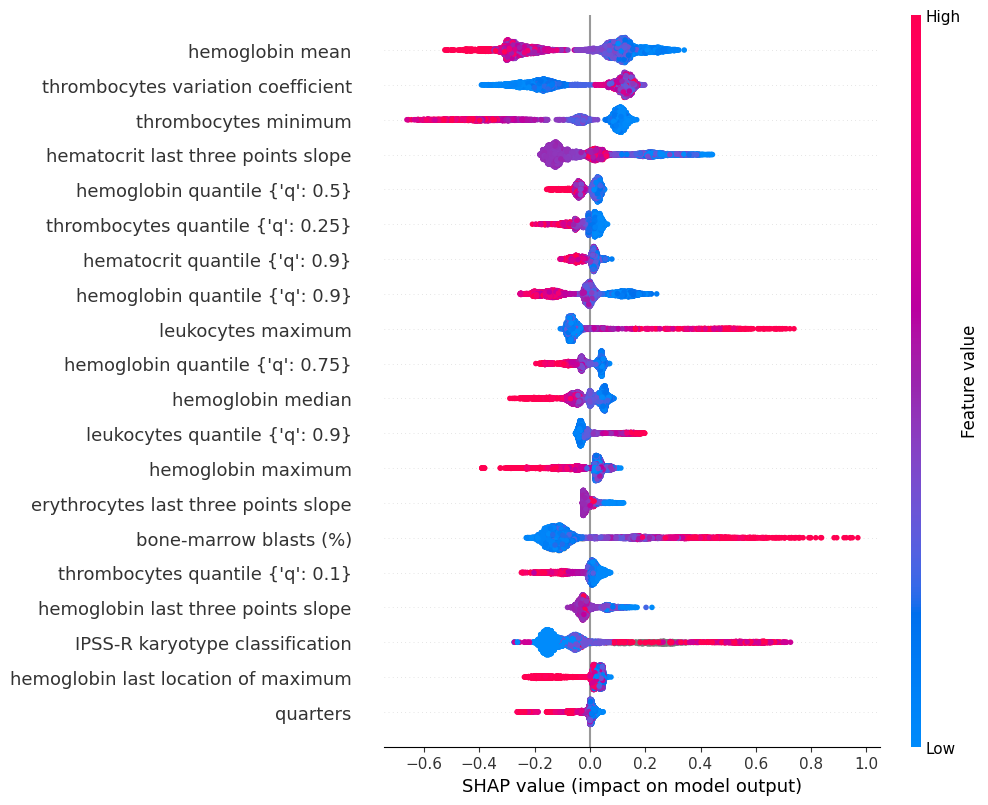

In [8]:
# get integer indices for your top_features list
feature_idx = [list(dataset.columns).index(f) for f in top_features]
feature_names = list(dataset.columns)
feature_names = [f.replace("_", " ") for f in feature_names]
feature_names = [f.replace("Thrombozyten", "thrombocytes")  for f in feature_names]
feature_names = [f.replace("Hämoglobin", "hemoglobin") for f in feature_names]
feature_names = [f.replace("Hämatokrit", "hematocrit") for f in feature_names]
feature_names = [f.replace("Leukozyten", "leukocytes") for f in feature_names]
feature_names = [f.replace("Erythrozyten", "erythrocytes") for f in feature_names]
feature_names[feature_names.index("blasts")] = "bone-marrow blasts (%)"
feature_names[feature_names.index("cyto")] = "IPSS-R karyotype classification"

# Create Explanation on full dataset
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=dataset,
    feature_names=feature_names
)

# Beeswarm plot of the top-20 most impactful features (auto-ranked)
shap.plots.beeswarm(explanation, max_display=20, show=False, group_remaining_features=False, order=feature_idx)
plt.savefig('shap_summary_plot_top_20_feat_imp.svg', format='svg', bbox_inches='tight')

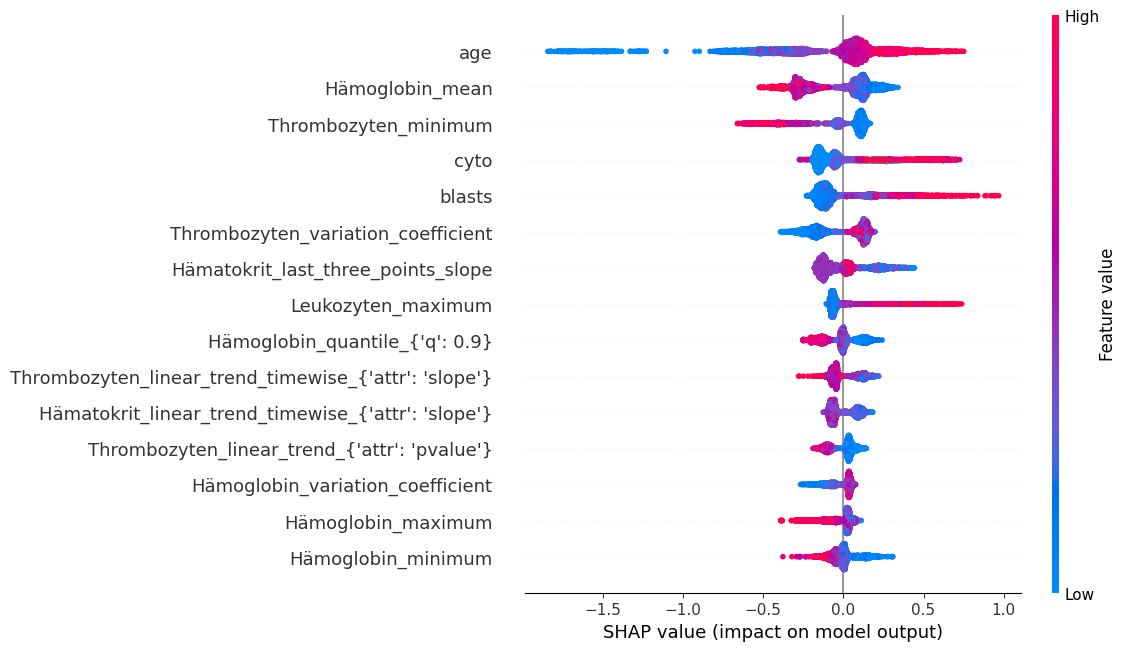

In [9]:
# 1. Create a SHAP Explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,  # base_values are needed but can be zeros here
    data=dataset,
    feature_names=dataset.columns
)

# 3. Plot
shap.plots.beeswarm(explanation, max_display=15, show=False, group_remaining_features=False)

# 4. Save
plt.savefig('shap_summary_plot_top_20_shap.svg', format='svg', bbox_inches='tight')



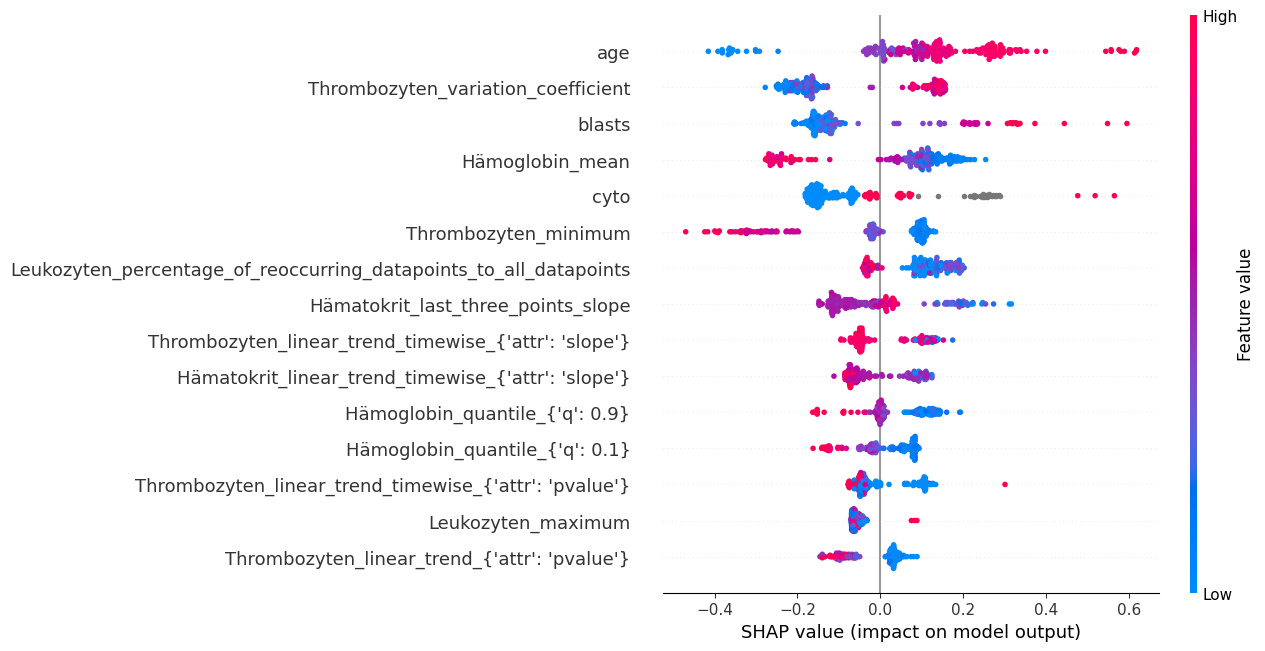

In [49]:
# SHAP values for the Mannheim validation set
explainer_val = shap.TreeExplainer(model)
shap_values_val = explainer.shap_values(val_dataset)

val_dataset = val_dataset[model.feature_names_in_]
# 1. Create a SHAP Explanation object
explanation_val = shap.Explanation(
    values=shap_values_val,
    base_values=explainer_val.expected_value,  # base_values are needed but can be zeros here
    data=val_dataset,
    feature_names=val_dataset.columns
)

# 2. Plot
shap.plots.beeswarm(explanation_val, max_display=15, show=False, group_remaining_features=False)

# 3. Save
plt.savefig('shap_summary_plot_top_20_shap_val.svg', format='svg', bbox_inches='tight')

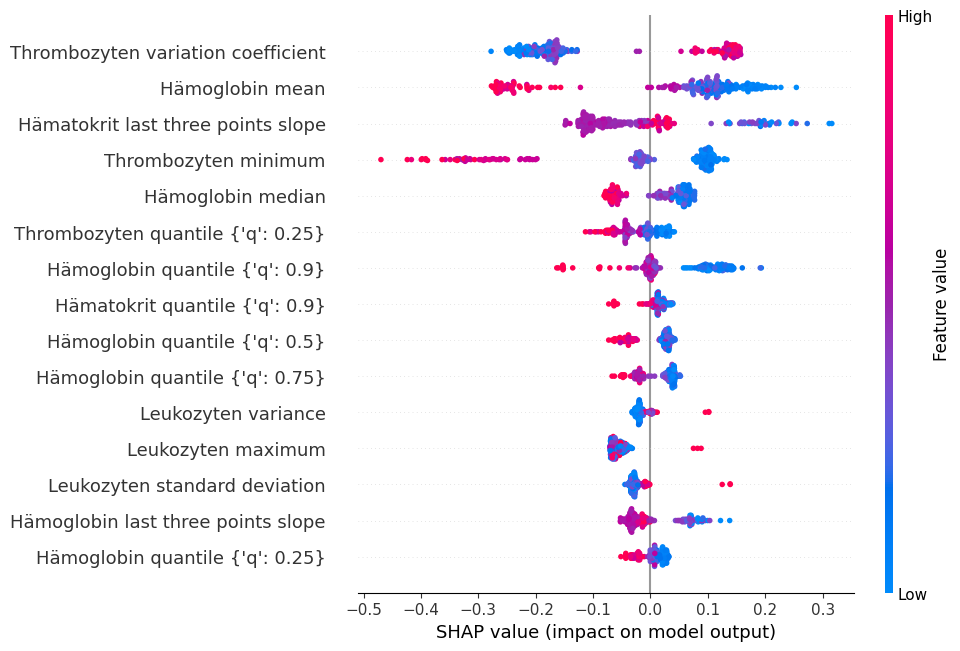

In [48]:
# get integer indices for your top_features list
feature_idx = [list(val_dataset.columns).index(f) for f in top_features]
feature_names = list(val_dataset.columns)
feature_names = [f.replace("_", " ") for f in feature_names]
feature_names[feature_names.index("blasts")] = "Bone-Marrow Blasts (%)"
feature_names[feature_names.index("cyto")] = "IPSS Karyotype classification"

explainer_val = shap.TreeExplainer(model)
shap_values_val = explainer.shap_values(val_dataset)

val_dataset = val_dataset[model.feature_names_in_]
# 1. Create a SHAP Explanation object
explanation_val = shap.Explanation(
    values=shap_values_val,
    base_values=explainer_val.expected_value,  # base_values are needed but can be zeros here
    data=val_dataset,
    feature_names=feature_names
)

# 3. Plot
shap.plots.beeswarm(explanation_val, max_display=15, show=False, group_remaining_features=False, order=feature_idx)

# 4. Save
plt.savefig('shap_summary_plot_top_20_feat_imp_val.svg', format='svg', bbox_inches='tight')